# College Fantasy Starter Pack (FFPy Edition)

Inspired by the [CFBD Starter Pack](https://collegefootballdata.gumroad.com/l/starter-pack), using your **local FFPy SQLite database** instead of raw API calls.

**Prerequisites:** `make bootstrap`, `CFBD_API_KEY` in `.env`, then:

```bash
make cfb-full-data SEASON=2024
```

If fantasy sections look empty after an earlier run, reload stats (CFBD response format was fixed):

```bash
make db.cfb-stats SEASON=2024
make db.cfb-players SEASON=2024
make db.cfb-fantasy SEASON=2024
make db.cfb-projections SEASON=2024
```

## Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

_cwd = Path.cwd()
REPO_ROOT = _cwd if (_cwd / "src" / "ffpy").exists() else _cwd.parent.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from ffpy.database import FFPyDatabase

SEASON = 2024
WEEK = 5
CONFERENCES = ("SEC", "Big Ten", "ACC")
SCORING_PRESET = "college_standard"

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

db = FFPyDatabase()
print(f"Database: {db.db_path}")

Database: /home/ricka/.ffpy/ffpy.db


## 1. Data readiness

Run this first. Sections below print a skip message when a table is empty.

In [2]:
audit = db.audit_cfb_data(season=SEASON)
coverage = pd.Series(audit).sort_index().rename("rows")
display(coverage.to_frame())

has_stats = audit.get("cfb_player_game_stats_rows", 0) > 0
has_fantasy = audit.get("cfb_fantasy_points_rows", 0) > 0
has_projections = audit.get("cfb_projections_rows", 0) > 0

if not has_stats:
    print("\n⚠ No player game stats — run: make db.cfb-stats SEASON=2024")
elif not has_fantasy:
    print("\n⚠ Stats loaded but no fantasy points — run: make db.cfb-fantasy SEASON=2024")
else:
    print("\n✓ Fantasy data ready — all analysis sections should populate.")

,rows
cfb_fantasy_points_rows,13676
cfb_games_rows,966
cfb_player_game_stats_rows,21371
cfb_players_rows,4212
cfb_projections_rows,27563
cfb_rosters_rows,27477
cfb_team_defense_stats_rows,510
cfb_teams_rows,33



✓ Fantasy data ready — all analysis sections should populate.


## 2. Teams & conferences

In [3]:
teams = pd.read_sql(
    """
    SELECT conference, COUNT(*) AS teams
    FROM cfb_teams
    WHERE season = ? AND conference IN (?, ?, ?)
    GROUP BY conference
    ORDER BY teams DESC
    """,
    db.conn,
    params=[SEASON, *CONFERENCES],
)
display(teams)

team_list = pd.read_sql(
    """
    SELECT school, abbreviation, conference, division
    FROM cfb_teams
    WHERE season = ? AND conference IN (?, ?, ?)
    ORDER BY conference, school
    """,
    db.conn,
    params=[SEASON, *CONFERENCES],
)
print(f"{len(team_list)} teams in scope")
display(team_list.head(15))

,conference,teams
0,ACC,17
1,SEC,16


33 teams in scope


,school,abbreviation,conference,division
0,Boston College,BC,ACC,None
1,California,CAL,ACC,None
2,Clemson,CLEM,ACC,None
3,Duke,DUKE,ACC,None
4,Florida State,FSU,ACC,None
5,Georgia Tech,GT,ACC,None
6,Louisville,LOU,ACC,None
7,Miami,MIA,ACC,None
8,NC State,NCSU,ACC,None
9,North Carolina,UNC,ACC,None


## 3. Rosters & eligible player pool

Works even before CFBD stats load — sourced from ESPN rosters + `cfb_players`.

conference,ACC,SEC
position,,
DST,678,648
K,88,96
QB,36,38
RB,98,95
TE,26,32
WR,543,525


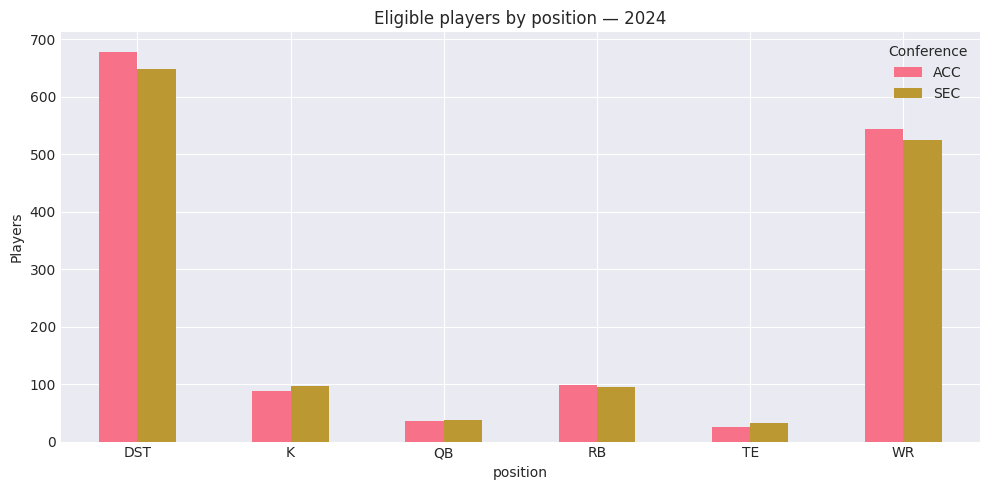

In [4]:
pool = pd.read_sql(
    """
    SELECT position, conference, COUNT(*) AS players
    FROM vw_cfb_eligible_players
    WHERE season = ? AND conference IN (?, ?, ?)
    GROUP BY position, conference
    ORDER BY position, conference
    """,
    db.conn,
    params=[SEASON, *CONFERENCES],
)

if pool.empty:
    print("No eligible players — run: make db.cfb-players SEASON=2024")
else:
    pool_pivot = pool.pivot(index="position", columns="conference", values="players").fillna(0)
    display(pool_pivot.astype(int))

    fig, ax = plt.subplots(figsize=(10, 5))
    pool_pivot.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(f"Eligible players by position — {SEASON}")
    ax.set_ylabel("Players")
    ax.legend(title="Conference")
    plt.tight_layout()
    plt.show()

## 4. Schedule snapshot

Conference games loaded from ESPN schedules.

In [5]:
games = pd.read_sql(
    """
    SELECT week, home_team, away_team, home_score, away_score, game_date
    FROM cfb_games
    WHERE season = ? AND week = ?
    ORDER BY game_date
    LIMIT 20
    """,
    db.conn,
    params=[SEASON, WEEK],
)
print(f"Week {WEEK} sample ({len(games)} games shown)")
display(games)

Week 5 sample (20 games shown)


,week,home_team,away_team,home_score,away_score,game_date
0,5,Temple Owls,Army Black Knights,14,42,2024-09-26T23:30Z
1,5,Miami Hurricanes,Virginia Tech Hokies,38,34,2024-09-27T23:30Z
2,5,Rutgers Scarlet Knights,Washington Huskies,21,18,2024-09-28T00:00Z
3,5,Ole Miss Rebels,Kentucky Wildcats,17,20,2024-09-28T16:00Z
4,5,Michigan Wolverines,Minnesota Golden Gophers,27,24,2024-09-28T16:00Z
5,5,Kansas State Wildcats,Oklahoma State Cowboys,42,20,2024-09-28T16:00Z
6,5,Baylor Bears,BYU Cougars,28,34,2024-09-28T16:00Z
7,5,Indiana Hoosiers,Maryland Terrapins,42,28,2024-09-28T16:00Z
8,5,Purdue Boilermakers,Nebraska Cornhuskers,10,28,2024-09-28T16:00Z
9,5,UConn Huskies,Buffalo Bulls,47,3,2024-09-28T16:00Z


## 5. Weekly box-score leaders (CFBD)

Top yardage producers from `cfb_player_game_stats`, aggregated across stat categories.

,full_name,position,team,conference,passing_yards,rushing_yards,receiving_yards,total_tds,total_yards
172,Jalen Milroe,QB,Alabama,SEC,374.00,117.00,0.00,4.00,491.00
97,Carson Beck,QB,Georgia,SEC,439.00,9.00,0.00,3.00,448.00
204,Garrett Nussmeier,QB,LSU,SEC,409.00,6.00,0.00,4.00,415.00
426,Cameron Ward,QB,Miami,ACC,343.00,57.00,0.00,5.00,400.00
181,Kyle McCord,QB,Syracuse,ACC,385.00,-17.00,0.00,4.00,368.00
91,Payton Thorne,QB,Auburn,SEC,338.00,23.00,0.00,3.00,361.00
619,Arch Manning,RB,Texas,SEC,324.00,33.00,0.00,3.00,357.00
15,Hank Bachmeier,QB,Wake Forest,ACC,254.00,65.00,5.00,1.00,324.00
379,Cade Klubnik,QB,Clemson,ACC,255.00,48.00,0.00,5.00,303.00
4,Tyler Shough,QB,Louisville,ACC,264.00,36.00,0.00,3.00,300.00


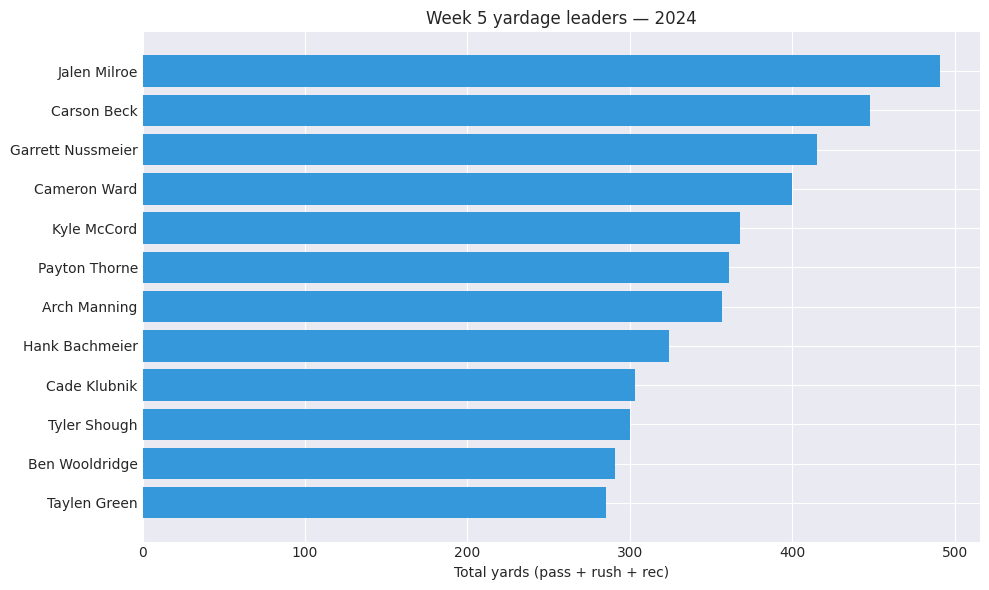

In [6]:
box = pd.read_sql(
    """
    SELECT
        s.cfbd_athlete_id,
        COALESCE(p.full_name, MAX(s.full_name)) AS full_name,
        COALESCE(p.position, 'UNK') AS position,
        t.school AS team,
        p.conference,
        SUM(s.passing_yards) AS passing_yards,
        SUM(s.rushing_yards) AS rushing_yards,
        SUM(s.receiving_yards) AS receiving_yards,
        SUM(s.passing_tds + s.rushing_tds + s.receiving_tds) AS total_tds
    FROM cfb_player_game_stats s
    LEFT JOIN cfb_players p
      ON s.player_id = p.player_id OR (s.cfbd_athlete_id = p.cfbd_athlete_id AND s.season = p.season)
    LEFT JOIN cfb_teams t ON s.team_key = t.team_key AND s.season = t.season
    WHERE s.season = ? AND s.week = ?
      AND (p.conference IN (?, ?, ?) OR p.conference IS NULL)
    GROUP BY s.cfbd_athlete_id, s.cfbd_game_id
    """,
    db.conn,
    params=[SEASON, WEEK, *CONFERENCES],
)

if box.empty:
    print("No box scores — run: make db.cfb-stats SEASON=2024")
else:
    box["total_yards"] = box["passing_yards"] + box["rushing_yards"] + box["receiving_yards"]
    leaders = box.nlargest(20, "total_yards")[
        [
            "full_name",
            "position",
            "team",
            "conference",
            "passing_yards",
            "rushing_yards",
            "receiving_yards",
            "total_tds",
            "total_yards",
        ]
    ]
    display(leaders)

    fig, ax = plt.subplots(figsize=(10, 6))
    plot_df = leaders.head(12).sort_values("total_yards")
    ax.barh(plot_df["full_name"], plot_df["total_yards"], color="#3498db")
    ax.set_xlabel("Total yards (pass + rush + rec)")
    ax.set_title(f"Week {WEEK} yardage leaders — {SEASON}")
    plt.tight_layout()
    plt.show()

## 6. Team defense (points allowed)

DST scoring inputs from CFBD `/games/teams`.

In [7]:
defense = pd.read_sql(
    """
    SELECT
        d.week,
        t.school AS team,
        t.conference,
        d.opponent_team_key,
        d.sacks,
        d.interceptions,
        d.fumbles_recovered,
        d.points_allowed
    FROM cfb_team_defense_stats d
    JOIN cfb_teams t ON d.team_key = t.team_key AND d.season = t.season
    WHERE d.season = ? AND d.week = ?
      AND t.conference IN (?, ?, ?)
    ORDER BY d.points_allowed ASC
    LIMIT 20
    """,
    db.conn,
    params=[SEASON, WEEK, *CONFERENCES],
)

if defense.empty:
    print("No defense stats — run: make db.cfb-stats SEASON=2024")
else:
    display(defense)

    season_def = pd.read_sql(
        """
        SELECT t.school AS team, t.conference, AVG(d.points_allowed) AS avg_pa
        FROM cfb_team_defense_stats d
        JOIN cfb_teams t ON d.team_key = t.team_key AND d.season = t.season
        WHERE d.season = ? AND t.conference IN (?, ?, ?)
        GROUP BY d.team_key
        ORDER BY avg_pa
        LIMIT 15
        """,
        db.conn,
        params=[SEASON, *CONFERENCES],
    )
    print("Best defenses by avg points allowed:")
    display(season_def)

,week,team,conference,opponent_team_key,sacks,interceptions,fumbles_recovered,points_allowed
0,5,LSU,SEC,south_alabama,0.00,0.00,0.00,0.00
1,5,Oklahoma,SEC,auburn,0.00,0.00,0.00,0.00
2,5,Auburn,SEC,oklahoma,0.00,0.00,0.00,0.00
3,5,Texas A&M,SEC,arkansas,0.00,0.00,0.00,0.00
4,5,Arkansas,SEC,texas_a&m,0.00,0.00,0.00,0.00
5,5,Alabama,SEC,georgia,0.00,0.00,0.00,0.00
6,5,Georgia,SEC,alabama,0.00,0.00,0.00,0.00
7,5,Ole Miss,SEC,kentucky,0.00,0.00,0.00,0.00
8,5,Kentucky,SEC,ole_miss,0.00,0.00,0.00,0.00
9,5,Mississippi State,SEC,texas,0.00,0.00,0.00,0.00


Best defenses by avg points allowed:


,team,conference,avg_pa
0,Alabama,SEC,0.00
1,Arkansas,SEC,0.00
2,Auburn,SEC,0.00
3,Boston College,ACC,0.00
4,California,ACC,0.00
5,Clemson,ACC,0.00
6,Duke,ACC,0.00
7,Florida,SEC,0.00
8,Florida State,ACC,0.00
9,Georgia,SEC,0.00


## 7. Fantasy weekly leaders

Requires `cfb_fantasy_points` (`college_standard` scoring, FCS discount applied).

,full_name,position,conference,team,actual_points,passing_yards,rushing_yards,receiving_yards,receptions,opponent_classification,fcs_discount_applied
0,Jalen Milroe,QB,SEC,Alabama,48.40,374.00,117.00,0.00,0.00,fbs,0
1,Cameron Ward,QB,ACC,Miami,40.85,343.00,57.00,0.00,0.00,fbs,0
2,Cade Klubnik,QB,ACC,Clemson,37.55,255.00,48.00,0.00,0.00,fbs,0
3,Garrett Nussmeier,QB,SEC,LSU,37.05,409.00,6.00,0.00,0.00,fbs,0
4,Caden Durham,RB,SEC,LSU,36.70,0.00,128.00,89.00,3.00,fbs,0
5,Star Thomas,RB,ACC,Duke,35.10,0.00,166.00,45.00,2.00,fbs,0
6,Tre Harris,WR,SEC,Ole Miss,34.60,0.00,0.00,176.00,11.00,fbs,0
7,Arch Manning,RB,SEC,Texas,33.50,324.00,33.00,0.00,0.00,fbs,0
8,Ryan Williams,WR,SEC,Alabama,29.70,0.00,0.00,177.00,6.00,fbs,0
9,Payton Thorne,QB,SEC,Auburn,29.20,338.00,23.00,0.00,0.00,fbs,0


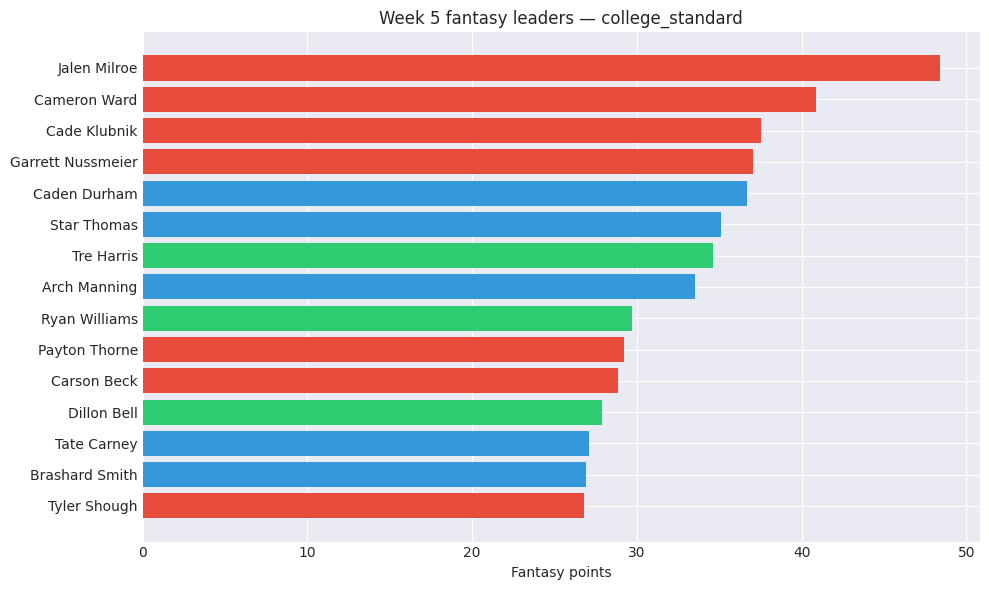

In [8]:
fantasy_leaders = pd.read_sql(
    """
    SELECT
        p.full_name,
        p.position,
        p.conference,
        t.school AS team,
        fp.actual_points,
        fp.passing_yards,
        fp.rushing_yards,
        fp.receiving_yards,
        fp.receptions,
        fp.opponent_classification,
        fp.fcs_discount_applied
    FROM cfb_fantasy_points fp
    JOIN cfb_players p ON fp.player_id = p.player_id
    LEFT JOIN cfb_teams t ON p.team_key = t.team_key AND p.season = t.season
    WHERE fp.season = ? AND fp.week = ? AND fp.scoring_preset = ?
      AND p.conference IN (?, ?, ?)
    ORDER BY fp.actual_points DESC
    LIMIT 25
    """,
    db.conn,
    params=[SEASON, WEEK, SCORING_PRESET, *CONFERENCES],
)

if fantasy_leaders.empty:
    print("No fantasy points — run make db.cfb-stats then make db.cfb-fantasy")
else:
    display(fantasy_leaders)
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_df = fantasy_leaders.head(15).sort_values("actual_points")
    colors = (
        plot_df["position"]
        .map({"QB": "#e74c3c", "RB": "#3498db", "WR": "#2ecc71", "TE": "#9b59b6", "K": "#f39c12"})
        .fillna("#95a5a6")
    )
    ax.barh(plot_df["full_name"], plot_df["actual_points"], color=colors)
    ax.set_xlabel("Fantasy points")
    ax.set_title(f"Week {WEEK} fantasy leaders — {SCORING_PRESET}")
    plt.tight_layout()
    plt.show()

## 8. Scoring distribution by position

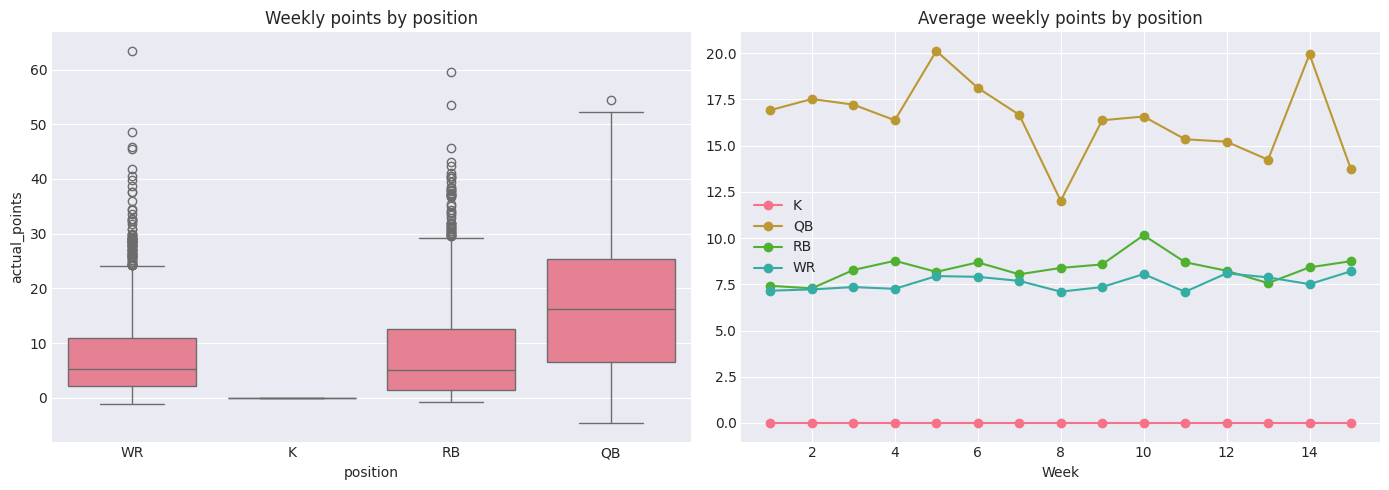

In [9]:
weekly = pd.read_sql(
    """
    SELECT fp.week, p.position, fp.actual_points
    FROM cfb_fantasy_points fp
    JOIN cfb_players p ON fp.player_id = p.player_id
    WHERE fp.season = ? AND fp.scoring_preset = ?
      AND p.conference IN (?, ?, ?)
      AND p.position IN ('QB', 'RB', 'WR', 'TE', 'K')
    """,
    db.conn,
    params=[SEASON, SCORING_PRESET, *CONFERENCES],
)

if weekly.empty:
    print("No fantasy points loaded.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(data=weekly, x="position", y="actual_points", ax=axes[0])
    axes[0].set_title("Weekly points by position")
    pos_avg = weekly.groupby(["week", "position"])["actual_points"].mean().reset_index()
    for pos in sorted(pos_avg["position"].unique()):
        subset = pos_avg[pos_avg["position"] == pos]
        axes[1].plot(subset["week"], subset["actual_points"], marker="o", label=pos)
    axes[1].set_title("Average weekly points by position")
    axes[1].set_xlabel("Week")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 9. FCS opponent discount

In [10]:
fcs = pd.read_sql(
    """
    SELECT
        fp.fcs_discount_applied,
        fp.opponent_classification,
        COUNT(*) AS player_weeks,
        ROUND(AVG(fp.actual_points), 2) AS avg_points
    FROM cfb_fantasy_points fp
    JOIN cfb_players p ON fp.player_id = p.player_id
    WHERE fp.season = ? AND fp.scoring_preset = ?
      AND p.conference IN (?, ?, ?)
    GROUP BY fp.fcs_discount_applied, fp.opponent_classification
    ORDER BY player_weeks DESC
    """,
    db.conn,
    params=[SEASON, SCORING_PRESET, *CONFERENCES],
)
display(fcs if not fcs.empty else pd.DataFrame({"note": ["No fantasy points yet"]}))

,fcs_discount_applied,opponent_classification,player_weeks,avg_points
0,0,fbs,11955,9.02
1,1,fcs,1324,6.82
2,0,None,397,10.00


## 10. Projections vs actuals

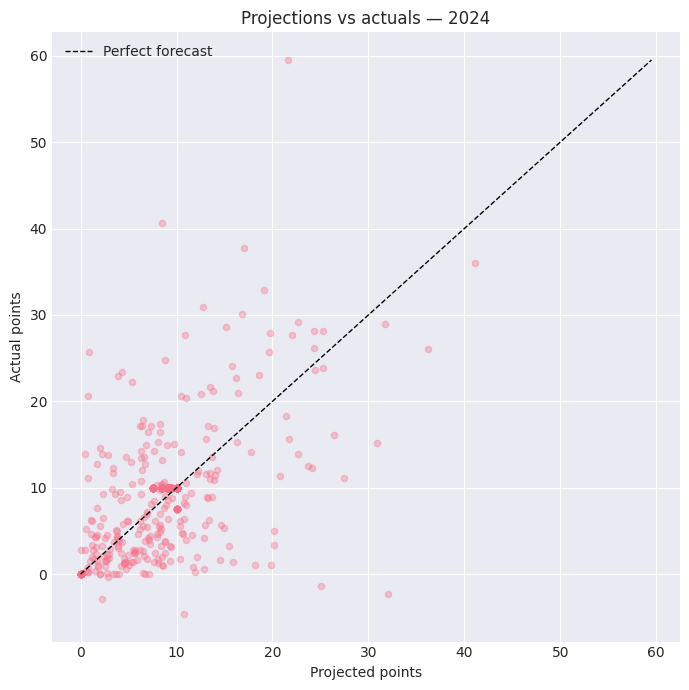

Mean absolute error: 2.17 points


In [11]:
proj_vs_actual = pd.read_sql(
    """
    SELECT
        pr.week,
        p.full_name,
        p.position,
        pr.projected_points,
        fp.actual_points,
        fp.actual_points - pr.projected_points AS diff
    FROM cfb_projections pr
    JOIN cfb_players p ON pr.player_id = p.player_id
    JOIN cfb_fantasy_points fp
      ON fp.player_id = pr.player_id AND fp.season = pr.season
     AND fp.week = pr.week AND fp.scoring_preset = ?
    WHERE pr.season = ? AND pr.model = 'historical'
      AND p.conference IN (?, ?, ?)
    """,
    db.conn,
    params=[SCORING_PRESET, SEASON, *CONFERENCES],
)

if proj_vs_actual.empty:
    print("No projections — run: make db.cfb-projections SEASON=2024")
else:
    fig, ax = plt.subplots(figsize=(7, 7))
    sample = proj_vs_actual.sample(min(800, len(proj_vs_actual)), random_state=42)
    ax.scatter(sample["projected_points"], sample["actual_points"], alpha=0.35, s=20)
    lim = max(sample["projected_points"].max(), sample["actual_points"].max())
    ax.plot([0, lim], [0, lim], "k--", lw=1, label="Perfect forecast")
    ax.set_xlabel("Projected points")
    ax.set_ylabel("Actual points")
    ax.set_title(f"Projections vs actuals — {SEASON}")
    ax.legend()
    plt.tight_layout()
    plt.show()
    mae = (proj_vs_actual["actual_points"] - proj_vs_actual["projected_points"]).abs().mean()
    print(f"Mean absolute error: {mae:.2f} points")

## 11. Season fantasy totals (skill positions)

In [12]:
season_totals = pd.read_sql(
    """
    SELECT
        p.full_name,
        p.position,
        p.conference,
        t.school AS team,
        SUM(fp.actual_points) AS season_points,
        COUNT(*) AS games_scored
    FROM cfb_fantasy_points fp
    JOIN cfb_players p ON fp.player_id = p.player_id
    LEFT JOIN cfb_teams t ON p.team_key = t.team_key AND p.season = t.season
    WHERE fp.season = ? AND fp.scoring_preset = ?
      AND p.conference IN (?, ?, ?)
      AND p.position IN ('QB', 'RB', 'WR', 'TE')
    GROUP BY p.player_id
    HAVING games_scored >= 3
    ORDER BY season_points DESC
    LIMIT 25
    """,
    db.conn,
    params=[SEASON, SCORING_PRESET, *CONFERENCES],
)
display(season_totals if not season_totals.empty else pd.DataFrame({"note": ["No fantasy points yet"]}))

,full_name,position,conference,team,season_points,games_scored
0,Cameron Ward,QB,ACC,Miami,378.83,12
1,Cade Klubnik,QB,ACC,Clemson,368.52,13
2,Jalen Milroe,QB,SEC,Alabama,357.60,12
3,Omarion Hampton,RB,ACC,North Carolina,333.15,12
4,Jaxson Dart,QB,SEC,Ole Miss,332.55,12
5,Kyle McCord,QB,ACC,Syracuse,313.11,12
6,Dylan Sampson,RB,SEC,Tennessee,304.52,12
7,Brashard Smith,RB,ACC,SMU,300.10,12
8,Lequint Allen,WR,ACC,Syracuse,294.88,12
9,Kevin Jennings,QB,ACC,SMU,289.60,12


## 12. Projection models: historical vs opponent_adj

Compare MAE when both models are loaded (`make db.cfb-projections-v2 SEASON=2024`).

In [ ]:
model_compare = pd.read_sql(
    """
    SELECT pr.model, p.position,
           AVG(ABS(fp.actual_points - pr.projected_points)) AS mae,
           COUNT(*) AS n
    FROM cfb_projections pr
    JOIN cfb_fantasy_points fp
      ON fp.player_id = pr.player_id AND fp.season = pr.season AND fp.week = pr.week
     AND fp.scoring_preset = ?
    JOIN cfb_players p ON pr.player_id = p.player_id
    WHERE pr.season = ? AND p.conference IN (?, ?, ?)
    GROUP BY pr.model, p.position
    ORDER BY pr.model, p.position
    """,
    db.conn,
    params=[SCORING_PRESET, SEASON, *CONFERENCES],
)

if model_compare.empty:
    print("Run: make db.cfb-projections SEASON=2024 && make db.cfb-projections-v2 SEASON=2024")
else:
    display(model_compare)
    if model_compare["model"].nunique() >= 2:
        pivot = model_compare.pivot(index="position", columns="model", values="mae")
        display(pivot)

## Next steps

- Change `SEASON` / `WEEK` in the setup cell and re-run
- Host a league: `make pickem-web` → `/api/cfb/leagues`
- Scoring rules: `config/scoring/college_standard.json`
- Full pipeline: `QUICKSTART.md` → College fantasy section